# Heart Disease Dataset - Machine Learning Pipeline
This notebook handles missing values, encodes categories, trains models, and exports the best pipeline.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report


## 1. Load Dataset & Rename Target

In [2]:
DATA_PATH = '../datasets/heart/2022/heart_2022_with_nans.csv'

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

# The user requested 'HeartDisease' as target. The 2022 dataset has 'HadHeartAttack'.
# We rename it to match requirements.
if 'HadHeartAttack' in df.columns and 'HeartDisease' not in df.columns:
    df.rename(columns={'HadHeartAttack': 'HeartDisease'}, inplace=True)

TARGET = 'HeartDisease'

# Drop rows where the target is NaN
initial_rows = df.shape[0]
df.dropna(subset=[TARGET], inplace=True)
print(f"Dropped {initial_rows - df.shape[0]} rows due to missing target values.")

# Map target to binary (Yes -> 1, No -> 0)
df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

df.head()


Loading dataset from: ../datasets/heart/2022/heart_2022_with_nans.csv
Dataset shape: (445132, 40)
Dropped 3065 rows due to missing target values.


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HeartDisease,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,0,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,0,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,0,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,0,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,0,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


## 2. Missing Values Analysis

Total overall missing values: 882386 (4.99%)


,Missing %
TetanusLast10Tdap,18.452859
PneumoVaxEver,17.239468
HIVTesting,14.773779
ChestScan,12.506701
CovidPos,11.339231
HighRiskLastYear,11.307110
BMI,10.882966
FluVaxLast12,10.513565
AlcoholDrinkers,10.391411
WeightInKilograms,9.380026


C:\Users\hp\AppData\Local\Temp\ipykernel_13152\3276960461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index[:15], y=missing_df['Missing %'][:15], palette='Reds_r')


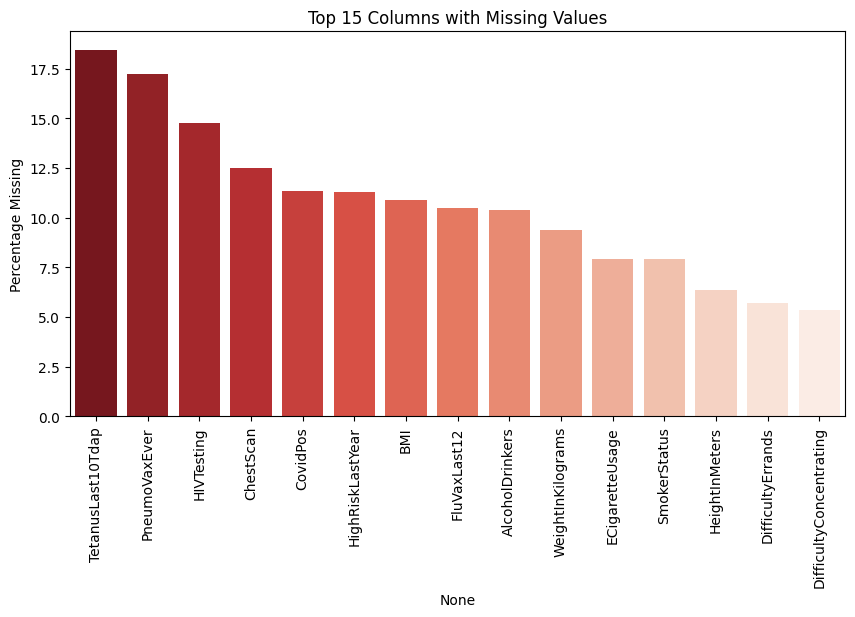

In [3]:
# Calculate missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False).to_frame(name='Missing %')

print(f"Total overall missing values: {df.isnull().sum().sum()} ({(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%)")
display(missing_df.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index[:15], y=missing_df['Missing %'][:15], palette='Reds_r')
plt.xticks(rotation=90)
plt.title('Top 15 Columns with Missing Values')
plt.ylabel('Percentage Missing')
plt.show()


## 3. Train-Test Split & Feature Engineering

In [4]:
# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Identify categorical and numerical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


Train set: (353653, 39), Test set: (88414, 39)
Numerical features (6): ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI']
Categorical features (33): ['State', 'Sex', 'GeneralHealth', 'LastCheckupTime', 'PhysicalActivities', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


C:\Users\hp\AppData\Local\Temp\ipykernel_13152\3826706306.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


## 4. Preprocessing Pipeline

In [5]:
# Imputation & Scaling for Numerical Features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Imputation & Encoding for Categorical Features
# Using OrdinalEncoder for efficiency with tree models and to keep dimensionality low for Logistic Regression
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Fitting preprocessor...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print("Preprocessing complete!")


Fitting preprocessor...
Preprocessing complete!


## 5. Model Training

In [6]:
# Initialize models optimized for large datasets
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_preprocessed, y_train)
    trained_models[name] = model
print("Training complete!")


Training Logistic Regression...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training Random Forest...
Training XGBoost...


c:\Users\hp\django\MediSense\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:55:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training complete!


## 6. Evaluation & Confusion Matrices

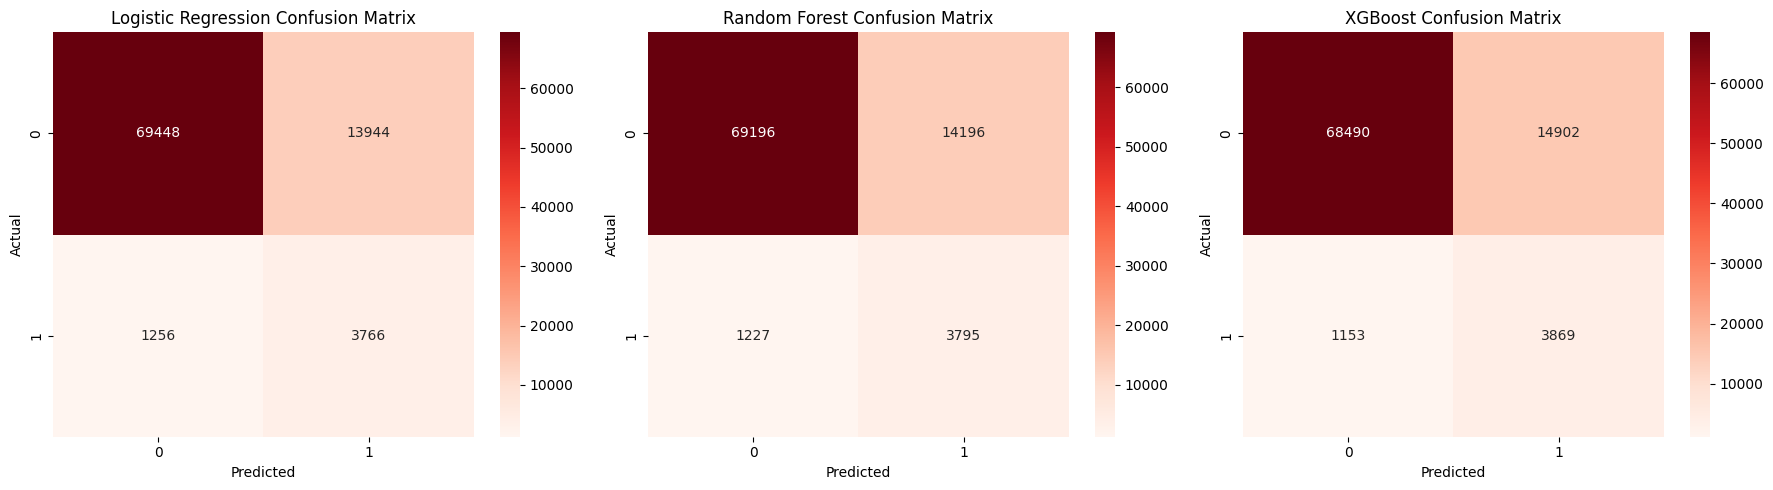

In [7]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_preprocessed)
    y_prob = model.predict_proba(X_test_preprocessed)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 7. Model Comparison & Best Model Selection

In [8]:
# Create comparison report
results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison Report:")
display(results_df)

# Select best model based on ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"\nBest Model selected based on ROC AUC: **{best_model_name}**")


Model Comparison Report:


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.828082,0.212648,0.749900,0.331339,0.878419
Random Forest,0.825559,0.210939,0.755675,0.329814,0.880140
XGBoost,0.818411,0.206116,0.770410,0.325222,0.884249



Best Model selected based on ROC AUC: **XGBoost**


## 8. Save Best Model Pipeline

In [9]:
# Bundle preprocessor and best model
os.makedirs('../models', exist_ok=True)
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

model_path = '../models/heart_model.pkl'
joblib.dump(full_pipeline, model_path)
print(f"Successfully saved complete {best_model_name} pipeline to {model_path}")


Successfully saved complete XGBoost pipeline to ../models/heart_model.pkl


## 9. Feature Importance Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_13152\3621379737.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


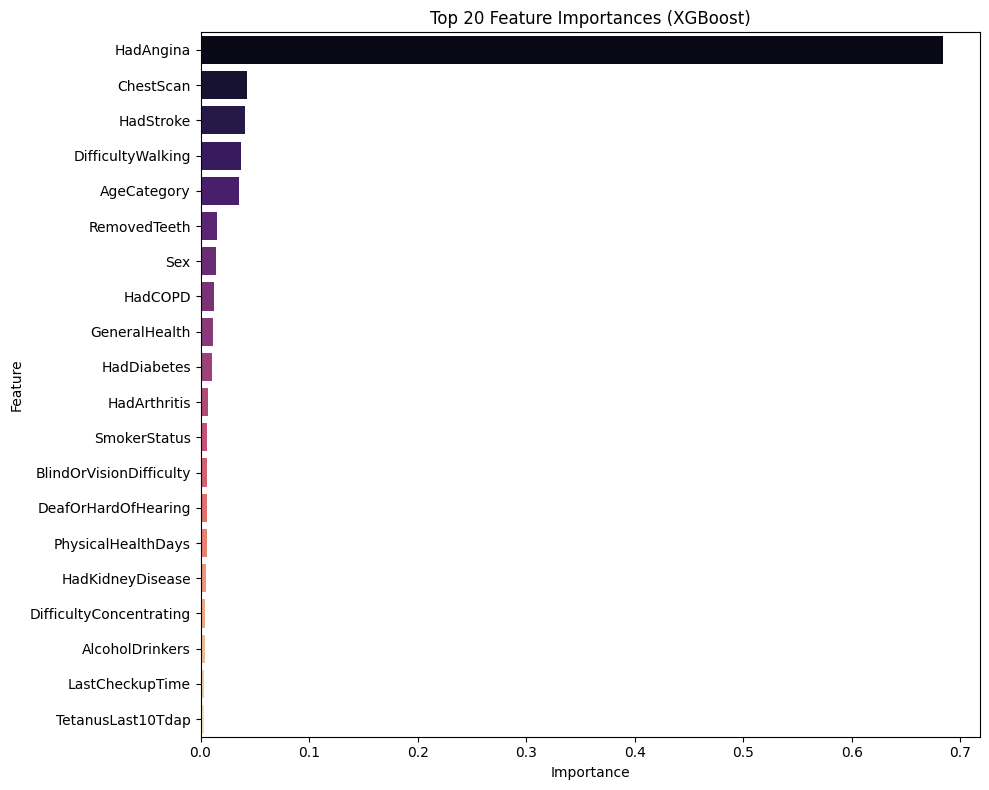

In [10]:
# Extract feature names
# Numeric features come first, then categorical
feature_names = numerical_features + categorical_features

if best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title(f'Top 20 Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()
